In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


data = pd.read_csv(
    r"C:\project\kaggle_project\practice\data\train.csv"
    )

print(data.columns)



Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


0      (21.714, 26.0]
1        (36.0, 45.5]
2      (21.714, 26.0]
3        (30.0, 36.0]
4        (30.0, 36.0]
            ...      
886      (26.0, 30.0]
887    (17.0, 21.714]
888               NaN
889    (21.714, 26.0]
890      (30.0, 36.0]
Name: AgeBin, Length: 891, dtype: category
Categories (7, interval[float64, right]): [(0.419, 17.0] < (17.0, 21.714] < (21.714, 26.0] < (26.0, 30.0] < (30.0, 36.0] < (36.0, 45.5] < (45.5, 80.0]]

C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1074988659.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = data.groupby("AgeBin")["Survived"].agg(["count", "mean", "median", "std"]).reset_index()
C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1074988659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


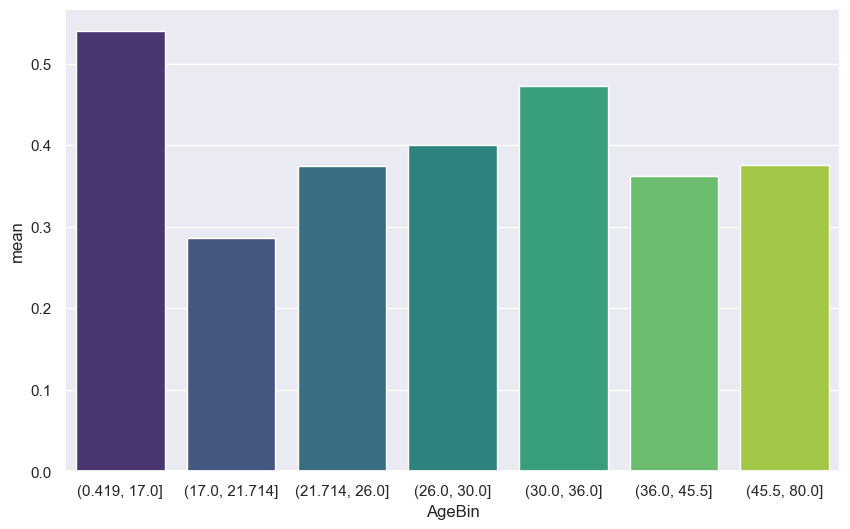

C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1074988659.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


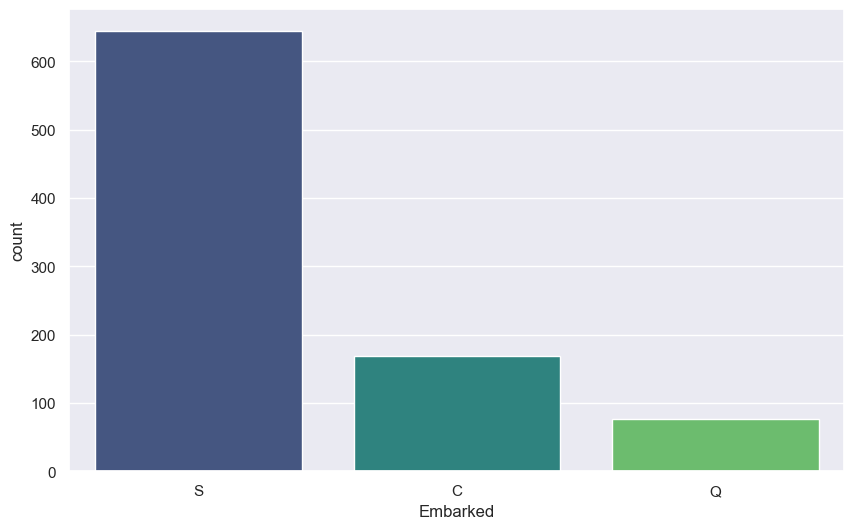

c:\Users\박중현\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1074988659.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


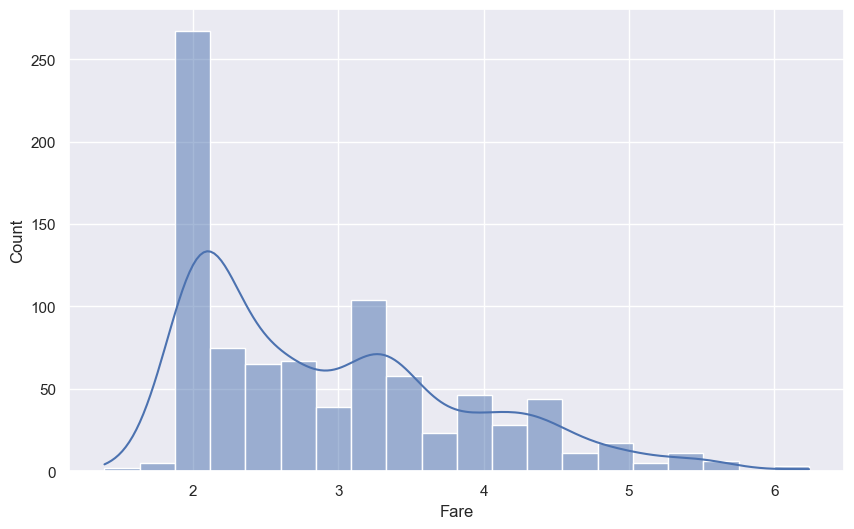

C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1074988659.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


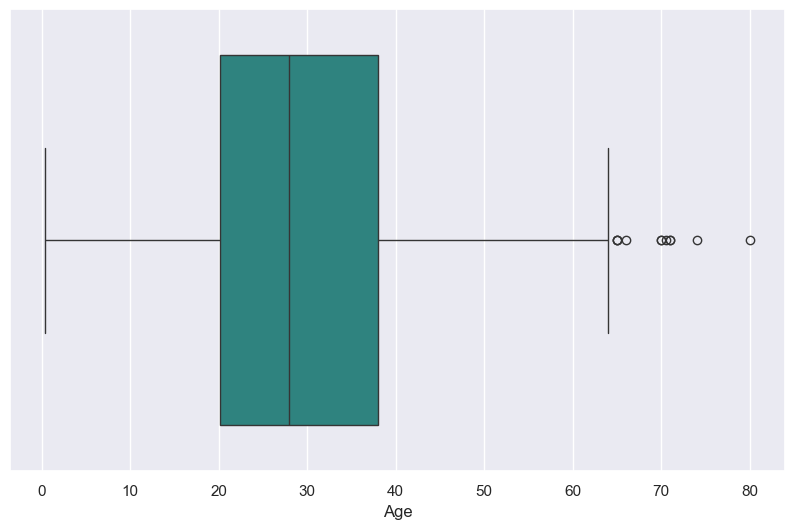

C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1074988659.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


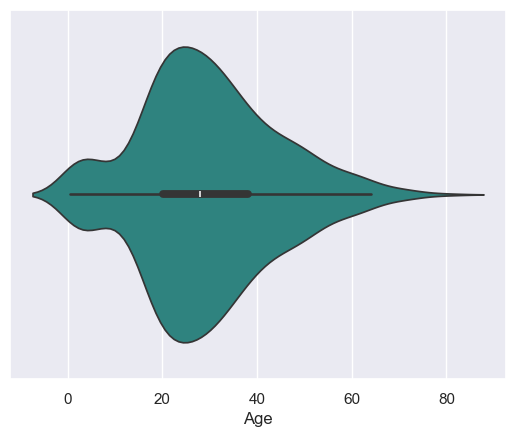

C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1074988659.py:52: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


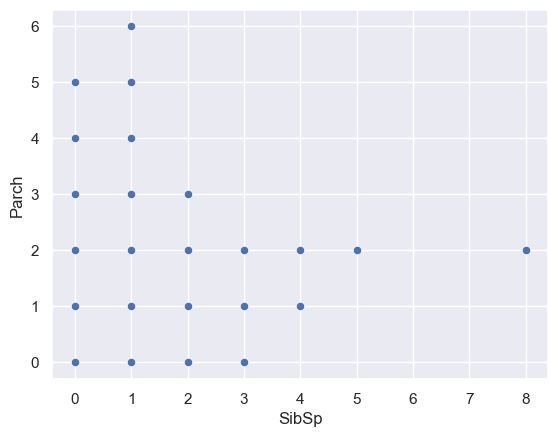

In [64]:
data['AgeBin'] = pd.qcut(data["Age"], q = 7, duplicates="drop")
display(
    data['AgeBin']
)

df = data.groupby("AgeBin")["Survived"].agg(["count", "mean", "median", "std"]).reset_index()
df["AgeBin"] = \
    df["AgeBin"].astype(str)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="AgeBin",
    y="mean",
    palette="viridis",
)
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(
    data=data,
    x="Embarked",
    palette='viridis',
)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=data,
    x=np.log(data["Fare"]),
    bins=20,
    palette='viridis',
    kde=True #부드러운 분포선
)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data,
    x="Age",
    palette='viridis'
)
plt.show()

sns.violinplot(
    data=data,
    x="Age",
    palette='viridis'
)
plt.show()

sns.scatterplot(
    data=data,
    x="SibSp",
    y="Parch",
    palette='viridis'
)
plt.show()
sns.set_theme(style="white")      # 흰 배경

C:\Users\박중현\AppData\Local\Temp\ipykernel_13056\1997203476.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


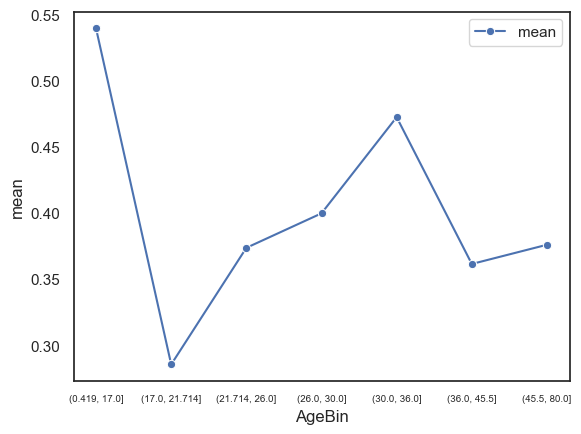

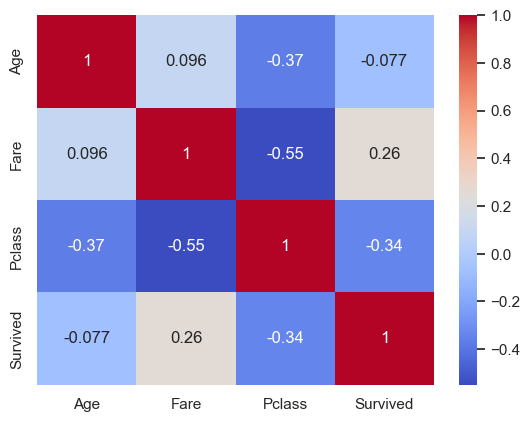

In [70]:
sns.lineplot(
    data=df,
    x="AgeBin",
    y="mean",
    marker='o',
    palette='viridis',
    label="mean"
)
plt.legend()
plt.xticks(fontsize=7)
plt.show()

corr = data[["Age", "Fare", "Pclass", "Survived"]].corr()
sns.heatmap(
    data=corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()